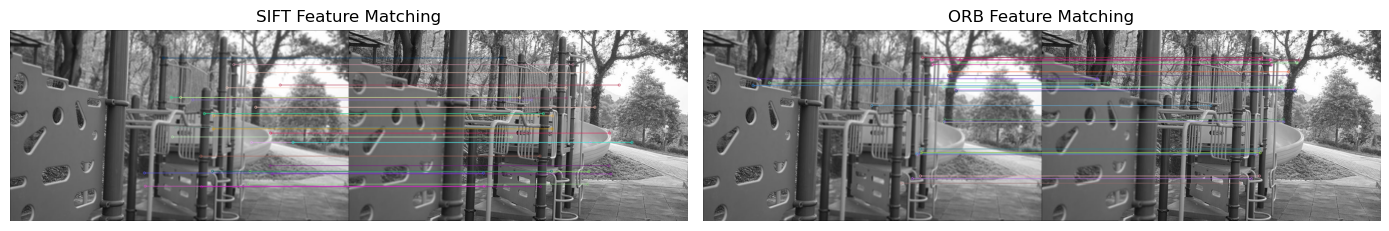

In [4]:
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Load Images
# -----------------------------
img1 = cv2.imread(r"C:\Users\YAMANU\Downloads\MFI-WHU_07_A.jpg", cv2.IMREAD_GRAYSCALE)   # Query image
img2 = cv2.imread(r"C:\Users\YAMANU\Downloads\MFI-WHU_07_B.jpg", cv2.IMREAD_GRAYSCALE) # Train image

# -----------------------------
# SIFT Feature Detection and Matching
# -----------------------------
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1_sift, des1_sift = sift.detectAndCompute(img1, None)
kp2_sift, des2_sift = sift.detectAndCompute(img2, None)

# Brute-Force Matcher (L2 norm for SIFT)
bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches_sift = bf_sift.match(des1_sift, des2_sift)

# Sort matches by distance (best matches first)
matches_sift = sorted(matches_sift, key=lambda x: x.distance)

# Draw top matches
sift_result = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift,
                              matches_sift[:30], None, flags=2)

# -----------------------------
# ORB Feature Detection and Matching
# -----------------------------
orb = cv2.ORB_create()

# Detect keypoints and descriptors
kp1_orb, des1_orb = orb.detectAndCompute(img1, None)
kp2_orb, des2_orb = orb.detectAndCompute(img2, None)

# Brute-Force Matcher (Hamming distance for ORB)
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_orb = bf_orb.match(des1_orb, des2_orb)

# Sort matches by distance
matches_orb = sorted(matches_orb, key=lambda x: x.distance)

# Draw top matches
orb_result = cv2.drawMatches(img1, kp1_orb, img2, kp2_orb, matches_orb[:30], None, flags=2)

# -----------------------------
# Display Results
# -----------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(sift_result)
plt.title('SIFT Feature Matching')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(orb_result)
plt.title('ORB Feature Matching')
plt.axis('off')

plt.tight_layout()
plt.show()
